In [27]:
from gensim.models import Word2Vec
import string
import re
from nltk.corpus import stopwords
with open(r'E:\Resume-Scoring-using-NLP-master\final\skills.txt',encoding="utf8") as f:
    content = f.readlines()
# you may also want to remove whitespace characters like `\n` at the end of each line
content = [x.strip() for x in content]

In [28]:
content[1]

'Data science is a "concept to unify statistics, data analysis, machine learning and their related methods" in order to "understand and analyze actual phenomena" with data. It employs techniques and theories drawn from many fields within the context of mathematics, statistics, information science, and computer science. Turing award winner Jim Gray imagined data science as a "fourth paradigm" of science (empirical, theoretical, computational and now data-driven) and asserted that "everything about science is changing because of the impact of information technology" and the data deluge.'

In [29]:
from nltk.tokenize import word_tokenize
import gensim
from gensim.models.phrases import Phraser, Phrases

**Preprocessing**

In [30]:
x=[]
for line in content:
    tokens=word_tokenize(line)
    tok=[w.lower() for w in tokens]
    table=str.maketrans('','',string.punctuation)
    strpp=[w.translate(table) for w in tok]
    words=[word for word in strpp if word.isalpha()]
    stop_words=set(stopwords.words('english'))
    words=[w for w in words if not w in stop_words]
    x.append(words)

In [31]:
texts=x

In [32]:
print(texts[6])

['william', 'cleveland', 'introduced', 'data', 'science', 'independent', 'discipline', 'extending', 'field', 'statistics', 'incorporate', 'advances', 'computing', 'data', 'article', 'data', 'science', 'action', 'plan', 'expanding', 'technical', 'areas', 'field', 'statistics', 'published', 'volume', 'april', 'edition', 'international', 'statistical', 'review', 'revue', 'internationale', 'de', 'statistique', 'report', 'cleveland', 'establishes', 'six', 'technical', 'areas', 'believed', 'encompass', 'field', 'data', 'science', 'multidisciplinary', 'investigations', 'models', 'methods', 'data', 'computing', 'data', 'pedagogy', 'tool', 'evaluation', 'theory']


**Removing commonly occuring words that are not useful**

In [33]:
with open('common.txt') as f:
    content2 = f.read()
ntexts=[]
l=len(texts)
for j in range(l):
    s=texts[j]
    res = [i for i in s if i not in content2]
    ntexts.append(res)
print(texts[6])

    

['william', 'cleveland', 'introduced', 'data', 'science', 'independent', 'discipline', 'extending', 'field', 'statistics', 'incorporate', 'advances', 'computing', 'data', 'article', 'data', 'science', 'action', 'plan', 'expanding', 'technical', 'areas', 'field', 'statistics', 'published', 'volume', 'april', 'edition', 'international', 'statistical', 'review', 'revue', 'internationale', 'de', 'statistique', 'report', 'cleveland', 'establishes', 'six', 'technical', 'areas', 'believed', 'encompass', 'field', 'data', 'science', 'multidisciplinary', 'investigations', 'models', 'methods', 'data', 'computing', 'data', 'pedagogy', 'tool', 'evaluation', 'theory']


In [34]:
print(ntexts[6])

['william', 'cleveland', 'introduced', 'data', 'independent', 'discipline', 'extending', 'statistics', 'incorporate', 'advances', 'computing', 'data', 'article', 'data', 'expanding', 'technical', 'areas', 'statistics', 'published', 'volume', 'april', 'edition', 'international', 'statistical', 'review', 'revue', 'internationale', 'statistique', 'report', 'cleveland', 'establishes', 'technical', 'areas', 'believed', 'encompass', 'data', 'multidisciplinary', 'investigations', 'models', 'methods', 'data', 'computing', 'data', 'pedagogy', 'evaluation', 'theory']


In [35]:
print(len(ntexts))
texts=ntexts

316


In [36]:
content=texts

In [37]:
from gensim.models.phrases import Phrases, Phraser

common_terms = {"of", "with", "without", "and", "or", "the", "a"}
ntexts = [[word for word in sentence if word not in common_terms] for sentence in ntexts]

# Create phrases
phrases = Phrases(ntexts, threshold=10)  # No 'common_terms' argument
bigram = Phraser(phrases)

all_sentences = list(bigram[ntexts])


In [38]:
import gensim
model = gensim.models.Word2Vec(
    all_sentences,
    vector_size=300,  
    min_count=2,
    workers=4,
    window=4
)

model.save("final.model")

wrds = list(model.wv.index_to_key)
print(f"Vocabulary size: {len(wrds)}")


Vocabulary size: 1007


**Testing**

In [39]:
z=model.wv.most_similar("learning")

In [40]:
print(z)

[('data', 0.3861986994743347), ('software', 0.36133164167404175), ('images', 0.3323310315608978), ('neural_network', 0.33230167627334595), ('layer', 0.3238828182220459), ('modeling', 0.31737539172172546), ('using', 0.3084707260131836), ('programming', 0.3013167083263397), ('approach', 0.2988460659980774), ('methods', 0.2962511479854584)]


### Resume Parsing

In [41]:
import spacy
nlp = spacy.load('en_core_web_sm')


In [42]:
import PyPDF2
import os
import collections
from os import listdir
from os.path import isfile, join
from io import StringIO
import pandas as pd
from collections import Counter
import en_core_web_sm
nlp = en_core_web_sm.load()
from spacy.matcher import PhraseMatcher

In [43]:
mypath=r'E:\Resume-Scoring-using-NLP-master\final\Resumes'
onlyfiles = [os.path.join(mypath, f) for f in os.listdir(mypath) if os.path.isfile(os.path.join(mypath, f))]


In [44]:
import collections
from PyPDF2 import PdfReader

def pdfextract(file):
    with open(file, 'rb') as pdf_file:
        reader = PdfReader(pdf_file)
        number_of_pages = len(reader.pages)  
        c = collections.Counter(range(number_of_pages))
        page_content = ""
        for i in c:
            page = reader.pages[i]
            page_content += page.extract_text()  
    return page_content.encode('utf-8')  


In [45]:
sim_words=[k[0] for k in model.wv.most_similar("learning")]

In [46]:
def create_bigram(words):
    common_terms = ["of", "with", "without", "and", "or", "the", "a"]
    x=words.split()
    phrases = Phrases(x, common_terms=common_terms)
    bigram = Phraser(phrases)
    all_sentences = list(bigram[x])
    
    

**Function to build candidate profile**

In [47]:
def create_profile(file):
    model=Word2Vec.load("final.model")
    text = str(pdfextract(file))
    text = text.replace("\\n", "")
    text = text.lower()
    stats = [nlp(text[0]) for text in model.wv.most_similar("statistics")]
    NLP = [nlp(text[0]) for text in model.wv.most_similar("data")]
    ML = [nlp(text[0]) for text in model.wv.most_similar("neural_network")]
    DL = [nlp(text[0]) for text in model.wv.most_similar("software")]
    python = [nlp(text[0]) for text in model.wv.most_similar("python")]
    Data_Engineering = [nlp(text[0]) for text in model.wv.most_similar("data")]
    print("*******************************************")
    matcher = PhraseMatcher(nlp.vocab)
    matcher.add('Stats', None, *stats)
    matcher.add('NLP', None, *NLP)
    matcher.add('ML', None, *ML)
    matcher.add('DL', None, *DL)
    matcher.add('Python', None, *python)
    matcher.add('DE', None, *Data_Engineering)
    doc = nlp(text)
    
    d = []  
    matches = matcher(doc)
    for match_id, start, end in matches:
        rule_id = nlp.vocab.strings[match_id]  
        span = doc[start : end]               
        d.append((rule_id, span.text))      
    keywords = "\n".join(f'{i[0]} {i[1]} ({j})' for i,j in Counter(d).items())
    print("KEYWORDS")
    print(keywords)
    
    ## convertimg string of keywords to dataframe
    df = pd.read_csv(StringIO(keywords),names = ['Keywords_List'])
    df1 = pd.DataFrame(df.Keywords_List.str.split(' ',1).tolist(),columns = ['Subject','Keyword'])
    df2 = pd.DataFrame(df1.Keyword.str.split('(',1).tolist(),columns = ['Keyword', 'Count'])
    df3 = pd.concat([df1['Subject'],df2['Keyword'], df2['Count']], axis =1) 
    df3['Count'] = df3['Count'].apply(lambda x: x.rstrip(")"))
    print("********************DF********************")
    print(df)
    
    base = os.path.basename(file)
    filename = os.path.splitext(base)[0]
    
       
    name = filename.split('_')
    print(name)
    name2 = name[0]
    name2 = name2.lower()
    name3 = pd.read_csv(StringIO(name2),names = ['Candidate Name'])
    
    dataf = pd.concat([name3['Candidate Name'], df3['Subject'], df3['Keyword'], df3['Count']], axis = 1)
    dataf['Candidate Name'].fillna(dataf['Candidate Name'].iloc[0], inplace = True)
    print("******************DATAF**************")
    print(dataf)

    return(dataf)

In [48]:
final_db=pd.DataFrame()
i=0
while i < len(onlyfiles):
    file=onlyfiles[i]
    dat=create_profile(file)

    final_db=final_db.append(dat)
    i+=1

*******************************************
KEYWORDS
NLP code (1)
DE code (1)
DL code (1)
ML data (5)
Stats data (5)
DL data (5)
Python data (5)
ML learning (4)
NLP learning (4)
Stats learning (4)
DE learning (4)
DL learning (4)
Python learning (4)
Stats images (1)
ML images (1)
NLP recognition (2)
Stats recognition (2)
DE recognition (2)
DL recognition (2)
Python recognition (2)
Stats architectures (1)
ML features (1)
DL features (1)
NLP systems (1)
DE systems (1)
NLP based (2)
DE based (2)
********************DF********************
              Keywords_List
0              NLP code (1)
1               DE code (1)
2               DL code (1)
3               ML data (5)
4            Stats data (5)
5               DL data (5)
6           Python data (5)
7           ML learning (4)
8          NLP learning (4)
9        Stats learning (4)
10          DE learning (4)
11          DL learning (4)
12      Python learning (4)
13         Stats images (1)
14            ML images (1)
15      NLP 

C:\Users\rohan\AppData\Local\Temp\ipykernel_14288\2746309428.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  final_db=final_db.append(dat)


*******************************************
KEYWORDS
NLP code (1)
DE code (1)
DL code (1)
NLP systems (1)
DE systems (1)
ML data (4)
Stats data (4)
DL data (4)
Python data (4)
NLP recognition (2)
Stats recognition (2)
DE recognition (2)
DL recognition (2)
Python recognition (2)
ML learning (5)
NLP learning (5)
Stats learning (5)
DE learning (5)
DL learning (5)
Python learning (5)
NLP based (1)
DE based (1)
********************DF********************
             Keywords_List
0             NLP code (1)
1              DE code (1)
2              DL code (1)
3          NLP systems (1)
4           DE systems (1)
5              ML data (4)
6           Stats data (4)
7              DL data (4)
8          Python data (4)
9      NLP recognition (2)
10   Stats recognition (2)
11      DE recognition (2)
12      DL recognition (2)
13  Python recognition (2)
14         ML learning (5)
15        NLP learning (5)
16      Stats learning (5)
17         DE learning (5)
18         DL learning (5)
19     

C:\Users\rohan\AppData\Local\Temp\ipykernel_14288\2746309428.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  final_db=final_db.append(dat)


*******************************************
KEYWORDS
ML learning (5)
NLP learning (5)
Stats learning (5)
DE learning (5)
DL learning (5)
Python learning (5)
Python javascript (1)
ML data (8)
Stats data (8)
DL data (8)
Python data (8)
NLP recognition (2)
Stats recognition (2)
DE recognition (2)
DL recognition (2)
Python recognition (2)
NLP based (1)
DE based (1)
Stats images (1)
ML images (1)
ML features (1)
DL features (1)
********************DF********************
             Keywords_List
0          ML learning (5)
1         NLP learning (5)
2       Stats learning (5)
3          DE learning (5)
4          DL learning (5)
5      Python learning (5)
6    Python javascript (1)
7              ML data (8)
8           Stats data (8)
9              DL data (8)
10         Python data (8)
11     NLP recognition (2)
12   Stats recognition (2)
13      DE recognition (2)
14      DL recognition (2)
15  Python recognition (2)
16           NLP based (1)
17            DE based (1)
18        Stats i

C:\Users\rohan\AppData\Local\Temp\ipykernel_14288\2746309428.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  final_db=final_db.append(dat)


*******************************************
KEYWORDS
NLP code (1)
DE code (1)
DL code (1)
NLP systems (1)
DE systems (1)
ML data (8)
Stats data (8)
DL data (8)
Python data (8)
NLP recognition (3)
Stats recognition (3)
DE recognition (3)
DL recognition (3)
Python recognition (3)
ML learning (4)
NLP learning (4)
Stats learning (4)
DE learning (4)
DL learning (4)
Python learning (4)
NLP based (1)
DE based (1)
********************DF********************
             Keywords_List
0             NLP code (1)
1              DE code (1)
2              DL code (1)
3          NLP systems (1)
4           DE systems (1)
5              ML data (8)
6           Stats data (8)
7              DL data (8)
8          Python data (8)
9      NLP recognition (3)
10   Stats recognition (3)
11      DE recognition (3)
12      DL recognition (3)
13  Python recognition (3)
14         ML learning (4)
15        NLP learning (4)
16      Stats learning (4)
17         DE learning (4)
18         DL learning (4)
19     

C:\Users\rohan\AppData\Local\Temp\ipykernel_14288\2746309428.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  final_db=final_db.append(dat)


*******************************************
KEYWORDS
Python javascript (1)
ML learning (1)
NLP learning (1)
Stats learning (1)
DE learning (1)
DL learning (1)
Python learning (1)
ML data (6)
Stats data (6)
DL data (6)
Python data (6)
Python making (1)
ML web (4)
NLP systems (2)
DE systems (2)
********************DF********************
            Keywords_List
0   Python javascript (1)
1         ML learning (1)
2        NLP learning (1)
3      Stats learning (1)
4         DE learning (1)
5         DL learning (1)
6     Python learning (1)
7             ML data (6)
8          Stats data (6)
9             DL data (6)
10        Python data (6)
11      Python making (1)
12             ML web (4)
13        NLP systems (2)
14         DE systems (2)
['Veronica Kurapati']
******************DATAF**************
       Candidate Name Subject      Keyword Count
0   veronica kurapati  Python  javascript      1
1   veronica kurapati      ML    learning      1
2   veronica kurapati     NLP    learnin

C:\Users\rohan\AppData\Local\Temp\ipykernel_14288\2746309428.py:7: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  final_db=final_db.append(dat)


**Counting words under each category and building the candidate profile**

In [49]:
final_db2 = final_db['Keyword'].groupby([final_db['Candidate Name'], final_db['Subject']]).count().unstack()
final_db2.reset_index(inplace = True)
final_db2.fillna(0,inplace=True)
candidate_data = final_db2.iloc[:,1:]
candidate_data.index = final_db2['Candidate Name']
cand=candidate_data.to_csv('candidate_profile.csv')
cand_profile=pd.read_csv('candidate_profile.csv')
cand_profile

,Candidate Name,DE,DL,ML,NLP,Python,Stats
0,akarsha,5,5,4,5,3,5
1,chaithanya velineni,5,4,2,5,3,3
2,nikitha,3,4,4,3,4,4
3,rohan kurapati,5,4,2,5,3,3
4,veronica kurapati,2,2,3,2,4,2


**Visualizing by matplotlib**

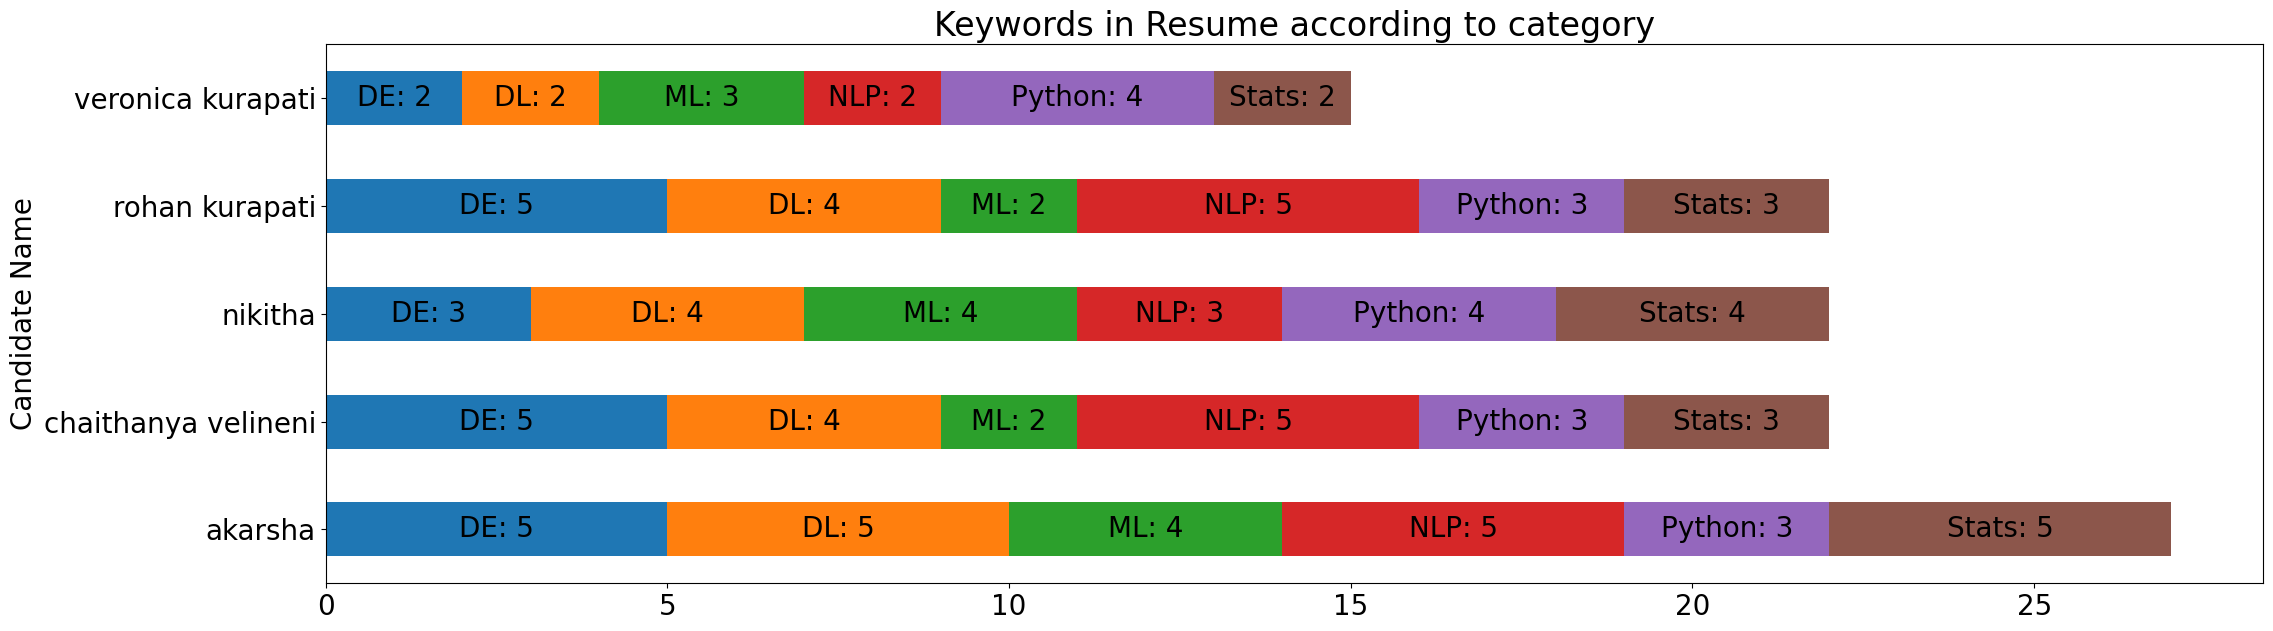

In [50]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({'font.size': 20})
ax = candidate_data.plot.barh(title="Keywords in Resume according to category", legend=False, figsize=(25,7), stacked=True)
skills = []
for j in candidate_data.columns:
    for i in candidate_data.index:
        skill = str(j)+": " + str(candidate_data.loc[i][j])
        skills.append(skill)
patches = ax.patches
for skill, rect in zip(skills, patches):
    width = rect.get_width()
    if width > 0:
        x = rect.get_x()
        y = rect.get_y()
        height = rect.get_height()
        ax.text(x + width/2., y + height/2., skill, ha='center', va='center')
plt.show()